In [ ]:
from google.colab import files
uploaded = files.upload()

Saving pdac_msk_2024_clinical_data.tsv to pdac_msk_2024_clinical_data.tsv


In [ ]:
import pandas as pd

# The file path is already available from previous steps
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'

try:
    df = pd.read_csv(tsv_file_path, sep='\t')
    print("TSV file imported successfully!")
    print("First 5 rows of the DataFrame:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{tsv_file_path}' was not found. Please ensure it has been uploaded.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

TSV file imported successfully!
First 5 rows of the DataFrame:
        Study ID Patient ID          Sample ID Adjuvant Treatment  \
0  pdac_msk_2024  P-0000142  P-0000142-T01-IM3   Gemcitabine Base   
1  pdac_msk_2024  P-0000783  P-0000783-T01-IM3                NaN   
2  pdac_msk_2024  P-0001304  P-0001304-T01-IM3                NaN   
3  pdac_msk_2024  P-0001518  P-0001518-T01-IM3                NaN   
4  pdac_msk_2024  P-0001548  P-0001548-T01-IM3                NaN   

  Age at Diagnosis KRAS Allele Selection  Evaluable for Allelic Imbalance  \
0               53                   NaN                            False   
1               62                   NaN                            False   
2               62                   NaN                            False   
3               59                   NaN                            False   
4               67                   NaN                            False   

          Ancestry  Ashkenazi Jewish Ancestry Autoimmune Di

## Exploratory Data Analysis (EDA)

In [ ]:
# Display basic information about the DataFrame, including data types and non-null values
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2336 entries, 0 to 2335
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Study ID                         2336 non-null   object 
 1   Patient ID                       2336 non-null   object 
 2   Sample ID                        2336 non-null   object 
 3   Adjuvant Treatment               469 non-null    object 
 4   Age at Diagnosis                 2336 non-null   object 
 5   KRAS Allele Selection            1157 non-null   object 
 6   Evaluable for Allelic Imbalance  2336 non-null   bool   
 7   Ancestry                         2336 non-null   object 
 8   Ashkenazi Jewish Ancestry        2332 non-null   object 
 9   Autoimmune Disease History       1480 non-null   object 
 10  Coronary Artery Disease History  1480 non-null   object 
 11  Cancer History                   1480 non-null   object 
 12  Canc

In [ ]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Diagnosis to Collection (Year),Fraction Genome Altered,MSI Score,Mutation Count,Overall Survival (Months),Number of Samples Per Patient,Sample coverage,TMB (nonsynonymous),Tumor Purity
count,2270.000000,2326.000000,2314.000000,2333.000000,2270.000000,2336.0,2336.000000,2336.000000,2335.000000
mean,0.405892,0.109938,0.428401,4.455208,16.960425,1.0,615.280822,4.124342,0.322343
std,1.646854,0.146556,1.753133,4.913949,14.210461,0.0,210.378441,4.457867,0.166587
min,-0.998851,0.000000,0.000000,1.000000,0.000000,1.0,105.000000,0.000000,0.050000
25%,0.000000,0.003400,0.000000,3.000000,6.385602,1.0,469.000000,2.594094,0.200000
50%,0.035576,0.043300,0.070000,4.000000,13.543721,1.0,605.500000,3.458792,0.290000
75%,0.197034,0.169925,0.330000,5.000000,23.274162,1.0,749.250000,4.922083,0.420000
max,37.804076,0.856900,35.570000,87.000000,83.234714,1.0,2176.000000,85.148614,1.040000


In [ ]:
# Check for missing values in each column
print("\nMissing Values per Column:")
display(df.isnull().sum())


Missing Values per Column:


,0
Study ID,0
Patient ID,0
Sample ID,0
Adjuvant Treatment,1867
Age at Diagnosis,0
KRAS Allele Selection,1179
Evaluable for Allelic Imbalance,0
Ancestry,0
Ashkenazi Jewish Ancestry,4
Autoimmune Disease History,856


In [ ]:
# Display the number of unique values for each column
print("\nNumber of Unique Values per Column:")
display(df.nunique())


Number of Unique Values per Column:


,0
Study ID,1
Patient ID,2336
Sample ID,2336
Adjuvant Treatment,3
Age at Diagnosis,62
KRAS Allele Selection,3
Evaluable for Allelic Imbalance,2
Ancestry,5
Ashkenazi Jewish Ancestry,2
Autoimmune Disease History,2


### Distribution of 'Age at Diagnosis'

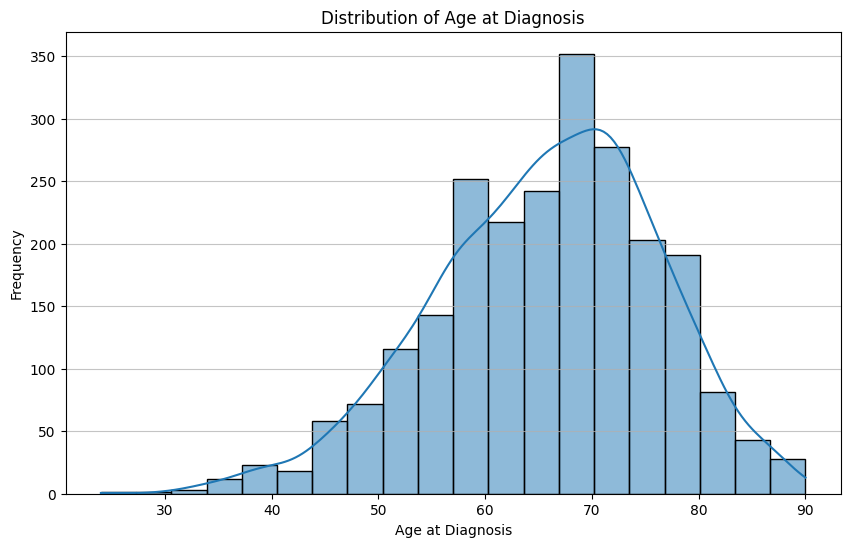

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert 'Age at Diagnosis' to numeric, coercing errors to NaN
df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')

# Drop rows where 'Age at Diagnosis' is NaN after conversion for plotting
df_age_clean = df.dropna(subset=['Age at Diagnosis'])

plt.figure(figsize=(10, 6))
sns.histplot(df_age_clean['Age at Diagnosis'], bins=20, kde=True)
plt.title('Distribution of Age at Diagnosis')
plt.xlabel('Age at Diagnosis')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Calculate descriptive statistics for 'Age at Diagnosis'
print("Descriptive statistics for 'Age at Diagnosis':")
display(df['Age at Diagnosis'].describe())

Descriptive statistics for 'Age at Diagnosis':


,Age at Diagnosis
count,2333.000000
mean,65.669096
std,10.489367
min,24.000000
25%,59.000000
50%,67.000000
75%,73.000000
max,90.000000


### Advanced Descriptive Statistics for Key Numerical Columns

In [ ]:
import pandas as pd
import numpy as np

# --- Code to ensure 'df' is defined and preprocessed (added for robustness) ---
# This section makes the cell self-contained against kernel resets.
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
try:
    df = pd.read_csv(tsv_file_path, sep='\t')
except FileNotFoundError:
    print(f"Error: The file '{tsv_file_path}' was not found. Please ensure it has been uploaded.")
    raise # Re-raise the error to stop further execution if file is critical
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
    raise # Re-raise the error

# Convert 'Age at Diagnosis' to numeric, coercing errors to NaN
# This step was previously done in another cell and is crucial for calculations.
df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
# ---

def calculate_advanced_stats(series, name):
    # Ensure the series is not empty and is numeric before calculating stats
    if series.empty or not pd.api.types.is_numeric_dtype(series):
        print(f"\n--- {name} ---")
        print(f"Cannot calculate statistics: Series is empty or not numeric.")
        return

    mean_val = series.mean()
    median_val = series.median()
    std_val = series.std()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    skew_val = series.skew()

    print(f"\n--- {name} ---")
    print(f"Mean: {mean_val:.2f}")
    print(f"Median: {median_val:.2f}")
    print(f"Standard Deviation: {std_val:.2f}")
    print(f"IQR (Q3-Q1): {iqr:.2f}")
    print(f"Skewness: {skew_val:.2f}")

# Calculate for 'Age at Diagnosis'
calculate_advanced_stats(df['Age at Diagnosis'].dropna(), 'Age at Diagnosis')

# Calculate for 'Overall Survival (Months)'
# Ensure 'Overall Survival (Months)' is numeric, though df.info() showed it as float64
if not pd.api.types.is_numeric_dtype(df['Overall Survival (Months)']):
    df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')
calculate_advanced_stats(df['Overall Survival (Months)'].dropna(), 'Overall Survival (Months')


--- Age at Diagnosis ---
Mean: 65.67
Median: 67.00
Standard Deviation: 10.49
IQR (Q3-Q1): 14.00
Skewness: -0.39

--- Overall Survival (Months ---
Mean: 16.96
Median: 13.54
Standard Deviation: 14.21
IQR (Q3-Q1): 16.89
Skewness: 1.35


In [ ]:
print(f"\nMin Age at Diagnosis: {df['Age at Diagnosis'].min():.0f}")
print(f"Max Age at Diagnosis: {df['Age at Diagnosis'].max():.0f}")


Min Age at Diagnosis: 24
Max Age at Diagnosis: 90


### Histogram with KDE for 'Age at Diagnosis'

This histogram, overlaid with a Kernel Density Estimate (KDE), visualizes the distribution of 'Age at Diagnosis'. The KDE helps to smooth out the histogram bars and show the underlying probability density function.

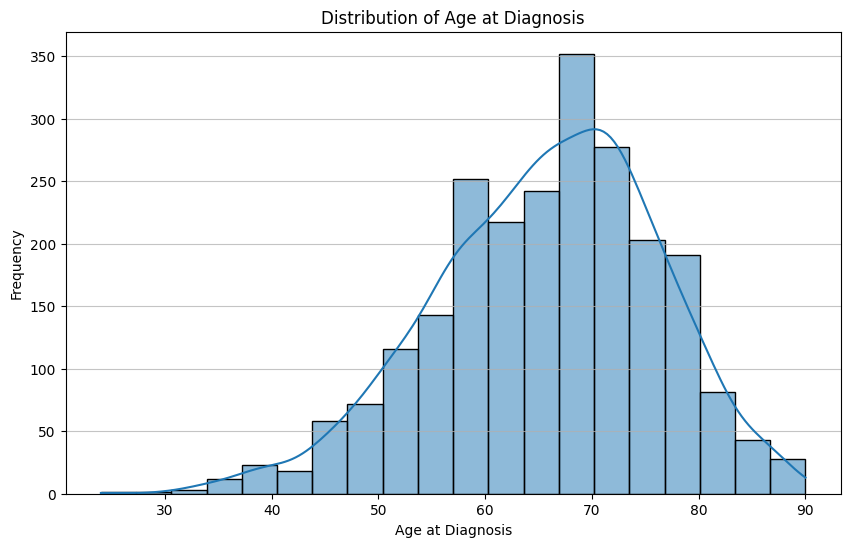

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Age at Diagnosis' is numeric, coercing errors to NaN
df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')

# Drop rows where 'Age at Diagnosis' is NaN for plotting clean data
df_age_clean = df.dropna(subset=['Age at Diagnosis'])

plt.figure(figsize=(10, 6))
sns.histplot(df_age_clean['Age at Diagnosis'], bins=20, kde=True)
plt.title('Distribution of Age at Diagnosis')
plt.xlabel('Age at Diagnosis')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Empirical Cumulative Distribution Function (ECDF) Plot for 'Age at Diagnosis'

The ECDF plot shows the proportion of observations that are less than or equal to a particular value. It's useful for understanding the overall distribution and identifying quartiles or specific percentiles.

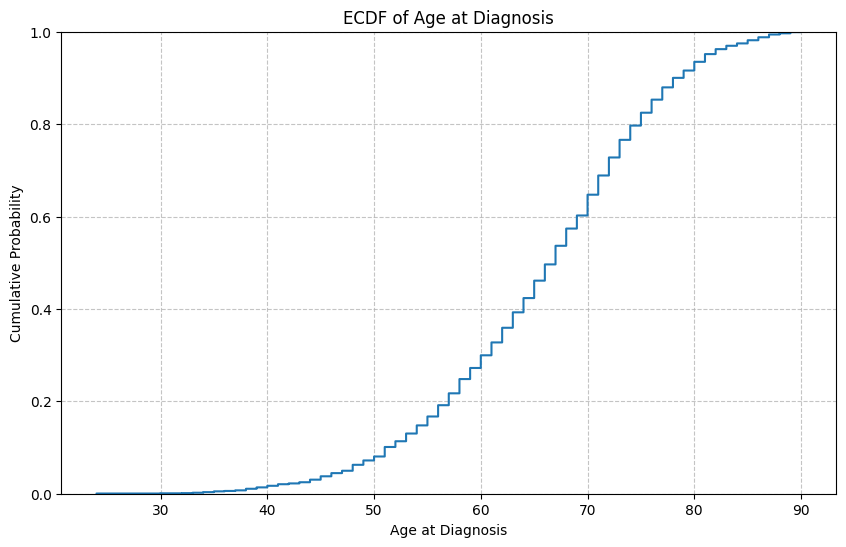

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Age at Diagnosis' is numeric, coercing errors to NaN
df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')

# Drop rows where 'Age at Diagnosis' is NaN for plotting clean data
df_age_clean = df.dropna(subset=['Age at Diagnosis'])

plt.figure(figsize=(10, 6))
sns.ecdfplot(df_age_clean['Age at Diagnosis'])
plt.title('ECDF of Age at Diagnosis')
plt.xlabel('Age at Diagnosis')
plt.ylabel('Cumulative Probability')
plt.grid(True, linestyle='--', alpha=0.75)
plt.show()

### Frequencies of KRAS Somatic Variants

This section visualizes the distribution of different `KRAS Somatic Variant` types found in the dataset. This helps in understanding the most common mutations in the KRAS gene within the cohort.

In [ ]:
# Calculate the frequencies of each KRAS Somatic Variant
kras_variant_counts = df['KRAS Somatic Variant'].value_counts().reset_index()
kras_variant_counts.columns = ['Variant Type', 'Frequency']

print("KRAS Somatic Variant Frequencies:")
display(kras_variant_counts)

KRAS Somatic Variant Frequencies:


,Variant Type,Frequency
0,G12D,892
1,G12V,706
2,G12R,352
3,Q61H,111
4,Other,70
5,Q61R,37
6,G12C,26


/tmp/ipykernel_1237/148956017.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Variant Type', y='Frequency', data=kras_variant_counts, palette='viridis')


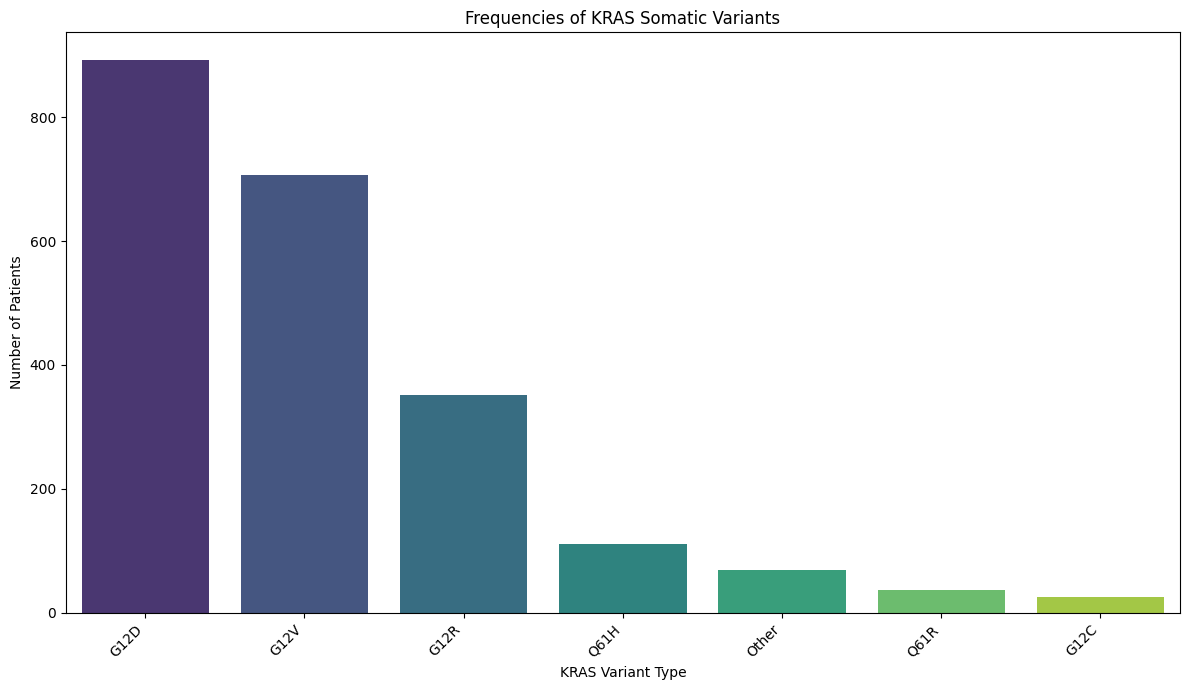

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Variant Type', y='Frequency', data=kras_variant_counts, palette='viridis')
plt.title('Frequencies of KRAS Somatic Variants')
plt.xlabel('KRAS Variant Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Note on TP53 Variants

As mentioned earlier, a dedicated column for `TP53` structural variants was not explicitly found in the dataset based on current column names. If you know of a column that contains this information (e.g., combined with other gene mutations, or named differently), please specify, and I can extract and visualize it.

### Continuous Genomic Metrics: Mutation Count and Fraction Genome Altered

This section analyzes the distribution and summary statistics for two key continuous genomic metrics: 'Mutation Count' and 'Fraction Genome Altered'. We will also check for skewness and apply a log transformation to 'Mutation Count' if it is heavily right-skewed, which is a common practice for tumor mutation burden data.


--- Mutation Count Analysis ---
Descriptive Statistics for Mutation Count:


,Mutation Count
count,2333.000000
mean,4.455208
std,4.913949
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,87.000000


Skewness of Mutation Count: 10.25


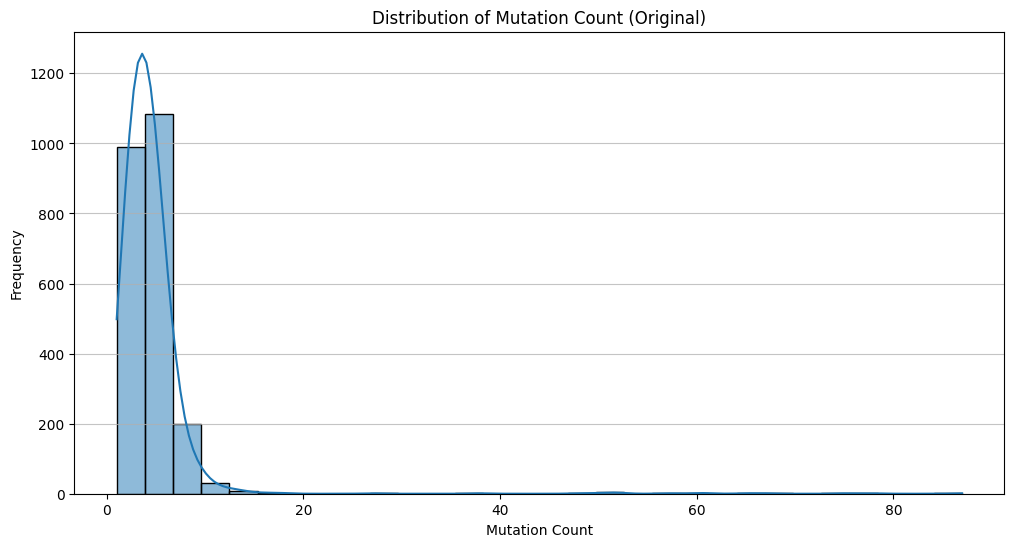


Mutation Count is heavily right-skewed. Applying log transformation (log1p).
Skewness of Log-Transformed Mutation Count: 0.95


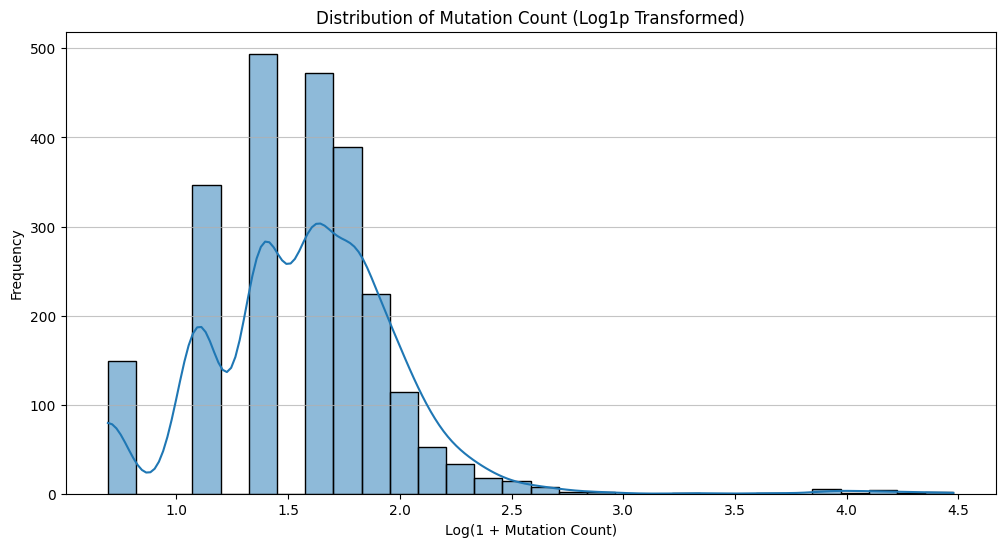

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        # If df cannot be loaded, subsequent code will fail, so raise error or exit gracefully
        raise

# --- Mutation Count Analysis ---
print("\n--- Mutation Count Analysis ---")
mutation_count_series = df['Mutation Count'].dropna()

if not mutation_count_series.empty:
    print("Descriptive Statistics for Mutation Count:")
    display(mutation_count_series.describe())
    skewness_mc = mutation_count_series.skew()
    print(f"Skewness of Mutation Count: {skewness_mc:.2f}")

    # Plot original distribution
    plt.figure(figsize=(12, 6))
    sns.histplot(mutation_count_series, bins=30, kde=True)
    plt.title('Distribution of Mutation Count (Original)')
    plt.xlabel('Mutation Count')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Check for heavy right skewness and apply log transformation
    if skewness_mc > 1: # A common threshold for heavy skewness
        print("\nMutation Count is heavily right-skewed. Applying log transformation (log1p).")
        mutation_count_log_transformed = np.log1p(mutation_count_series)
        skewness_mc_log = mutation_count_log_transformed.skew()
        print(f"Skewness of Log-Transformed Mutation Count: {skewness_mc_log:.2f}")

        plt.figure(figsize=(12, 6))
        sns.histplot(mutation_count_log_transformed, bins=30, kde=True)
        plt.title('Distribution of Mutation Count (Log1p Transformed)')
        plt.xlabel('Log(1 + Mutation Count)')
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.75)
        plt.show()
else:
    print("Mutation Count series is empty or contains no valid numeric data.")


--- Fraction Genome Altered Analysis ---
Descriptive Statistics for Fraction Genome Altered:


,Fraction Genome Altered
count,2326.000000
mean,0.109938
std,0.146556
min,0.000000
25%,0.003400
50%,0.043300
75%,0.169925
max,0.856900


Skewness of Fraction Genome Altered: 1.77


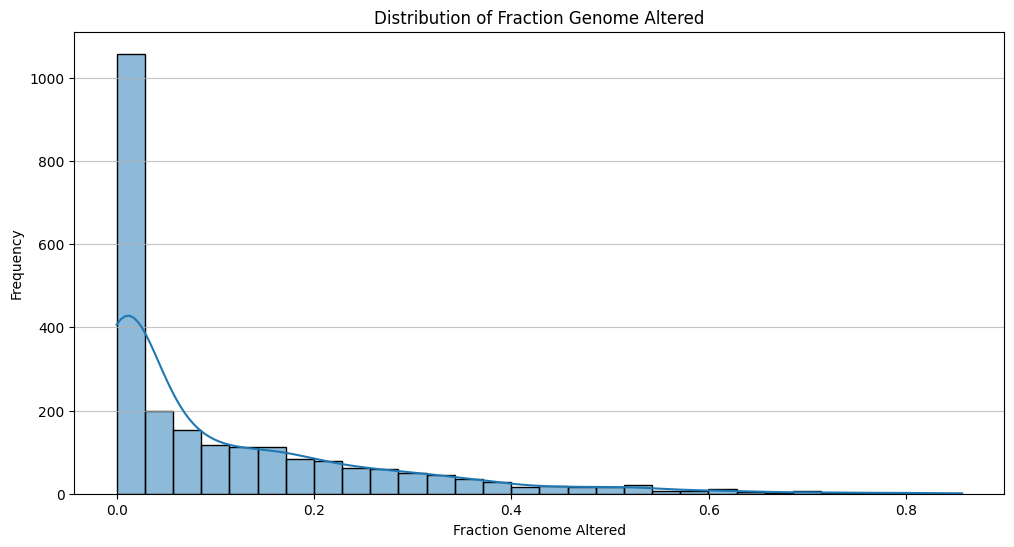

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Fraction Genome Altered Analysis ---
print("\n--- Fraction Genome Altered Analysis ---")
fr_genome_altered_series = df['Fraction Genome Altered'].dropna()

if not fr_genome_altered_series.empty:
    print("Descriptive Statistics for Fraction Genome Altered:")
    display(fr_genome_altered_series.describe())
    skewness_fga = fr_genome_altered_series.skew()
    print(f"Skewness of Fraction Genome Altered: {skewness_fga:.2f}")

    # Plot distribution
    plt.figure(figsize=(12, 6))
    sns.histplot(fr_genome_altered_series, bins=30, kde=True)
    plt.title('Distribution of Fraction Genome Altered')
    plt.xlabel('Fraction Genome Altered')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("Fraction Genome Altered series is empty or contains no valid numeric data.")

### Categorical Drivers: KRAS Somatic Variant Frequencies (including wild-type)

We previously looked at the counts of identified KRAS somatic variants. Now, let's explicitly consider the distinction between identified somatic variants and potential 'wild-type' cases, which are often represented by `NaN` values in the variant column. This gives a complete picture of the `KRAS Somatic Variant` status in the cohort.


--- KRAS Somatic Variant Frequencies (including missing values) ---


,Variant Type,Frequency
0,G12D,892
1,G12V,706
2,G12R,352
3,Wild-type/Unknown,142
4,Q61H,111
5,Other,70
6,Q61R,37
7,G12C,26


/tmp/ipykernel_1237/316247255.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Variant Type', y='Frequency', data=kras_full_counts, palette='viridis')


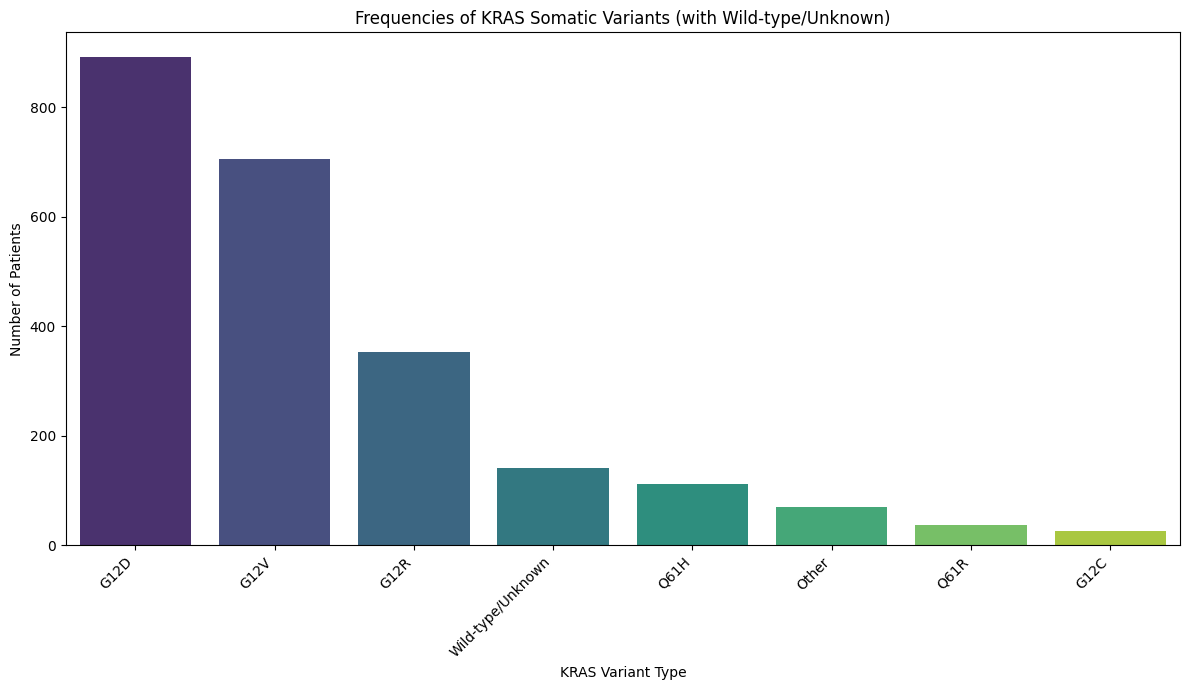

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

print("\n--- KRAS Somatic Variant Frequencies (including missing values) ---")
kras_full_counts = df['KRAS Somatic Variant'].value_counts(dropna=False).reset_index()
kras_full_counts.columns = ['Variant Type', 'Frequency']

# Replace NaN with 'Wild-type/Unknown' for better visualization
kras_full_counts['Variant Type'] = kras_full_counts['Variant Type'].fillna('Wild-type/Unknown')

display(kras_full_counts)

plt.figure(figsize=(12, 7))
sns.barplot(x='Variant Type', y='Frequency', data=kras_full_counts, palette='viridis')
plt.title('Frequencies of KRAS Somatic Variants (with Wild-type/Unknown)')
plt.xlabel('KRAS Variant Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Mutation Typology: Copy Number State and KRAS Somatic Variant vs. Age at Diagnosis

This section explores the variety within 'Copy Number State' and 'KRAS Somatic Variant' and how these structural alterations might relate to 'Age at Diagnosis'. We will use `value_counts()` to inspect the diversity of these categorical variables and then visualize the age distribution across their different categories.


--- Copy Number State Value Counts ---


,count
Copy Number State,
NaN,1179
Balanced,676
Gain,186
LOH,129
CNLOH,62
Loss after WGD,56
Amp,48


/tmp/ipykernel_1237/4140306072.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Copy Number State', y='Age at Diagnosis', data=df.dropna(subset=['Copy Number State', 'Age at Diagnosis']), palette='pastel')


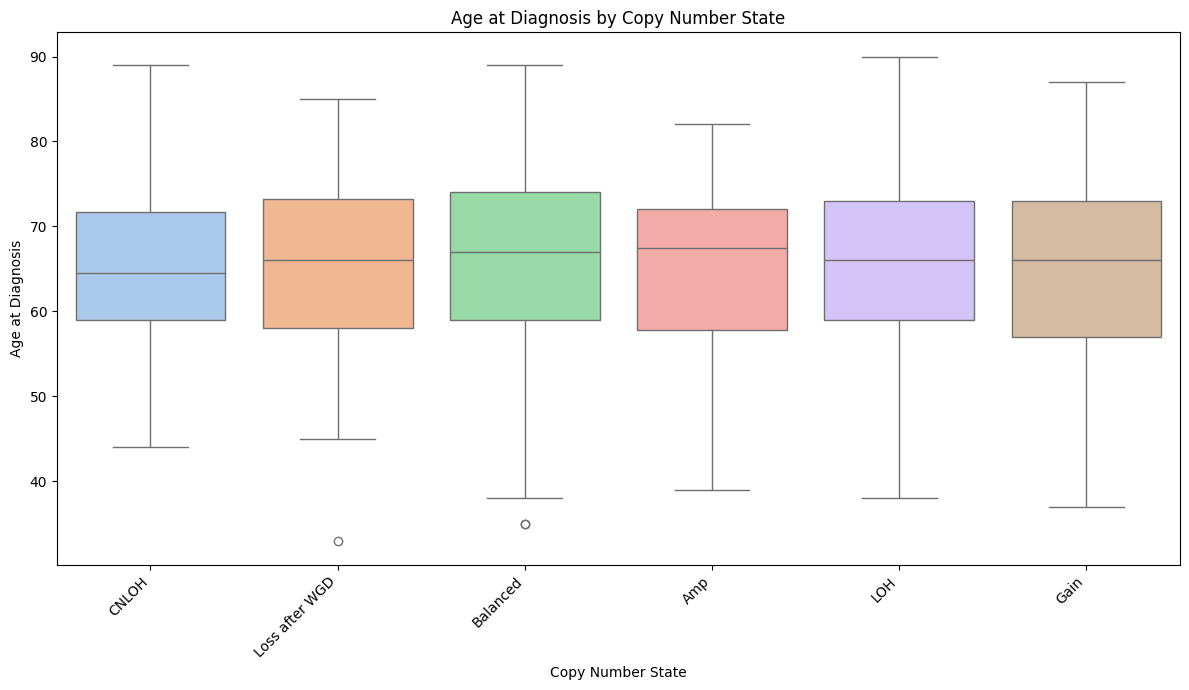

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Copy Number State Analysis ---
print("\n--- Copy Number State Value Counts ---")
cn_state_counts = df['Copy Number State'].value_counts(dropna=False)
display(cn_state_counts)

if not df['Copy Number State'].dropna().empty and not df['Age at Diagnosis'].dropna().empty:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Copy Number State', y='Age at Diagnosis', data=df.dropna(subset=['Copy Number State', 'Age at Diagnosis']), palette='pastel')
    plt.title('Age at Diagnosis by Copy Number State')
    plt.xlabel('Copy Number State')
    plt.ylabel('Age at Diagnosis')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: 'Copy Number State' or 'Age at Diagnosis' has no valid data for plotting.")


--- KRAS Somatic Variant Value Counts (excluding NaN) ---


,count
KRAS Somatic Variant,
G12D,892
G12V,706
G12R,352
Q61H,111
Other,70
Q61R,37
G12C,26


/tmp/ipykernel_1237/2799757929.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='KRAS Somatic Variant', y='Age at Diagnosis', data=df.dropna(subset=['KRAS Somatic Variant', 'Age at Diagnosis']), palette='muted')


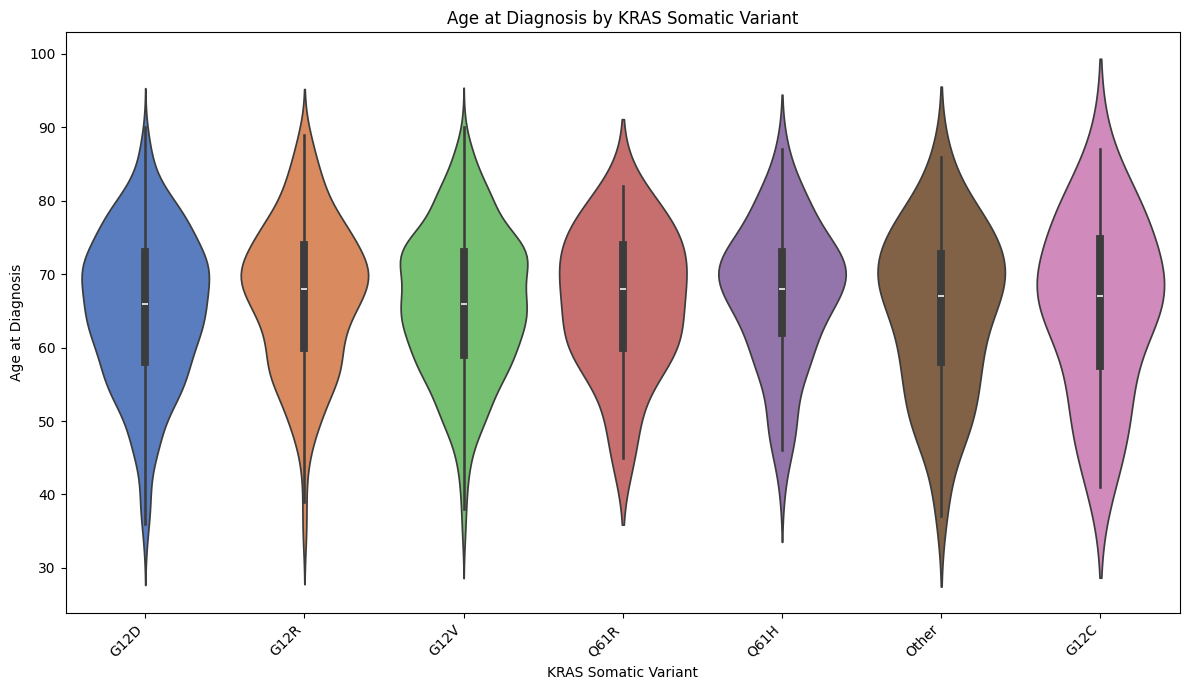

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- KRAS Somatic Variant vs. Age at Diagnosis ---
print("\n--- KRAS Somatic Variant Value Counts (excluding NaN) ---")
kras_variant_counts_nonan = df['KRAS Somatic Variant'].value_counts()
display(kras_variant_counts_nonan)

if not df['KRAS Somatic Variant'].dropna().empty and not df['Age at Diagnosis'].dropna().empty:
    plt.figure(figsize=(12, 7))
    sns.violinplot(x='KRAS Somatic Variant', y='Age at Diagnosis', data=df.dropna(subset=['KRAS Somatic Variant', 'Age at Diagnosis']), palette='muted')
    plt.title('Age at Diagnosis by KRAS Somatic Variant')
    plt.xlabel('KRAS Somatic Variant')
    plt.ylabel('Age at Diagnosis')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: 'KRAS Somatic Variant' or 'Age at Diagnosis' has no valid data for plotting.")

### Confounder Profiling: Age at Diagnosis by Sex, Ancestry, and MSI Type

This section aims to identify potential confounding factors by examining if 'Age at Diagnosis' is heavily clustered within specific demographic or molecular subgroups ('Sex', 'Ancestry', 'MSI Type'). Such clustering could introduce bias in downstream analyses.


--- Age at Diagnosis by Sex ---


,count
Sex,
Male,1214
Female,1122


/tmp/ipykernel_1237/2733557756.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y='Age at Diagnosis', data=df.dropna(subset=['Sex', 'Age at Diagnosis']), palette='coolwarm')


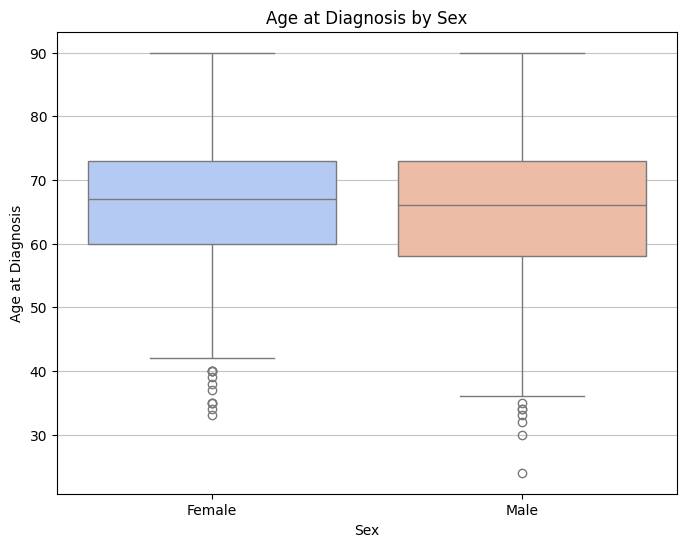

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Age at Diagnosis by Sex ---
print("\n--- Age at Diagnosis by Sex ---")
sex_counts = df['Sex'].value_counts(dropna=False)
display(sex_counts)

if not df['Sex'].dropna().empty and not df['Age at Diagnosis'].dropna().empty:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Sex', y='Age at Diagnosis', data=df.dropna(subset=['Sex', 'Age at Diagnosis']), palette='coolwarm')
    plt.title('Age at Diagnosis by Sex')
    plt.xlabel('Sex')
    plt.ylabel('Age at Diagnosis')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("Cannot plot: 'Sex' or 'Age at Diagnosis' has no valid data for plotting.")


--- Age at Diagnosis by Ancestry ---


,count
Ancestry,
European (EUR),1889
Admixed/other,213
East Asian (EAS),113
African (AFR),82
South Asian (SAS),39


/tmp/ipykernel_1237/704086681.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ancestry ', y='Age at Diagnosis', data=df.dropna(subset=['Ancestry ', 'Age at Diagnosis']), palette='viridis')


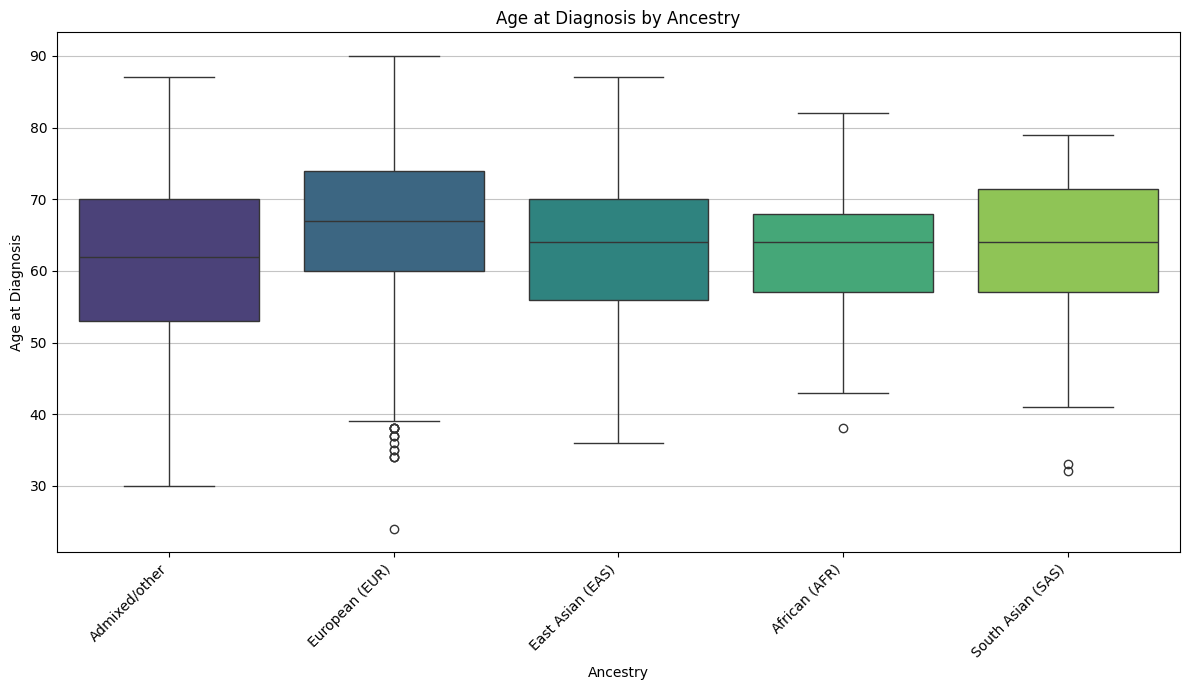

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Age at Diagnosis by Ancestry ---
print("\n--- Age at Diagnosis by Ancestry ---")
# Corrected column name from 'Ancestry' to 'Ancestry '
ancestry_counts = df['Ancestry '].value_counts(dropna=False)
display(ancestry_counts)

if not df['Ancestry '].dropna().empty and not df['Age at Diagnosis'].dropna().empty:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Ancestry ', y='Age at Diagnosis', data=df.dropna(subset=['Ancestry ', 'Age at Diagnosis']), palette='viridis')
    plt.title('Age at Diagnosis by Ancestry')
    plt.xlabel('Ancestry')
    plt.ylabel('Age at Diagnosis')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: 'Ancestry ' or 'Age at Diagnosis' has no valid data for plotting.")


--- Age at Diagnosis by MSI Type ---


,count
MSI Type,
NaN,1217
Stable,1003
Do not report,89
Indeterminate,21
Instable,6


/tmp/ipykernel_1237/2204358722.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MSI Type', y='Age at Diagnosis', data=df.dropna(subset=['MSI Type', 'Age at Diagnosis']), palette='plasma')


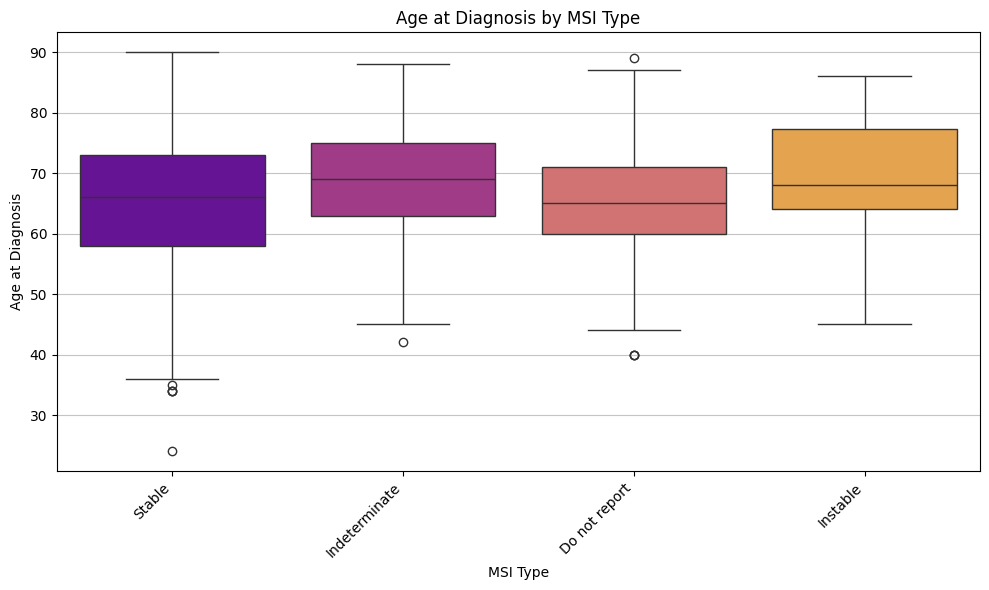

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Age at Diagnosis by MSI Type ---
print("\n--- Age at Diagnosis by MSI Type ---")
msi_type_counts = df['MSI Type'].value_counts(dropna=False)
display(msi_type_counts)

if not df['MSI Type'].dropna().empty and not df['Age at Diagnosis'].dropna().empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='MSI Type', y='Age at Diagnosis', data=df.dropna(subset=['MSI Type', 'Age at Diagnosis']), palette='plasma')
    plt.title('Age at Diagnosis by MSI Type')
    plt.xlabel('MSI Type')
    plt.ylabel('Age at Diagnosis')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: 'MSI Type' or 'Age at Diagnosis' has no valid data for plotting, or contains too many NaNs.")
    print("MSI Type has a significant number of missing values (NaNs). This might limit the utility of this particular visualization.")

### Data Integrity Checks: Duplicate Patient and Sample IDs

It's crucial to check for duplicate entries in 'Patient ID' and 'Sample ID' to ensure data integrity and to understand the sample structure. Multiple samples per patient might require a specific handling strategy, such as selecting a primary sample or aggregating data.

In [ ]:
import pandas as pd

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Check for Duplicate Patient IDs ---
print("\n--- Checking for Duplicate Patient IDs ---")
duplicate_patient_ids = df[df.duplicated(subset=['Patient ID'], keep=False)]

if not duplicate_patient_ids.empty:
    print(f"Found {duplicate_patient_ids['Patient ID'].nunique()} patients with multiple samples.")
    print("First 5 instances of patients with multiple samples:")
    display(duplicate_patient_ids.sort_values('Patient ID').head())
    print("\nConsideration: If a single patient has multiple samples, you will need to decide on a strategy (e.g., keep the primary tumor sample, or aggregate data) based on your research goals.")
else:
    print("No duplicate Patient IDs found. Each patient has a unique entry.")

# --- Check for Duplicate Sample IDs ---
print("\n--- Checking for Duplicate Sample IDs ---")
duplicate_sample_ids = df[df.duplicated(subset=['Sample ID'], keep=False)]

if not duplicate_sample_ids.empty:
    print(f"Found {duplicate_sample_ids['Sample ID'].nunique()} unique Sample IDs with duplicate entries.")
    print("First 5 instances of duplicate sample IDs:")
    display(duplicate_sample_ids.sort_values('Sample ID').head())
    print("Note: Duplicate Sample IDs could indicate data entry errors or specific experimental designs. Review these entries carefully.")
else:
    print("No duplicate Sample IDs found. Each sample has a unique entry.")


--- Checking for Duplicate Patient IDs ---
No duplicate Patient IDs found. Each patient has a unique entry.

--- Checking for Duplicate Sample IDs ---
No duplicate Sample IDs found. Each sample has a unique entry.


### Relationship between Age at Diagnosis and Overall Survival

This section explores the relationship between a patient's 'Age at Diagnosis' and their 'Overall Survival (Months)'. We will use a scatter plot to visualize any trends and calculate the Pearson correlation coefficient to quantify the strength and direction of this relationship.

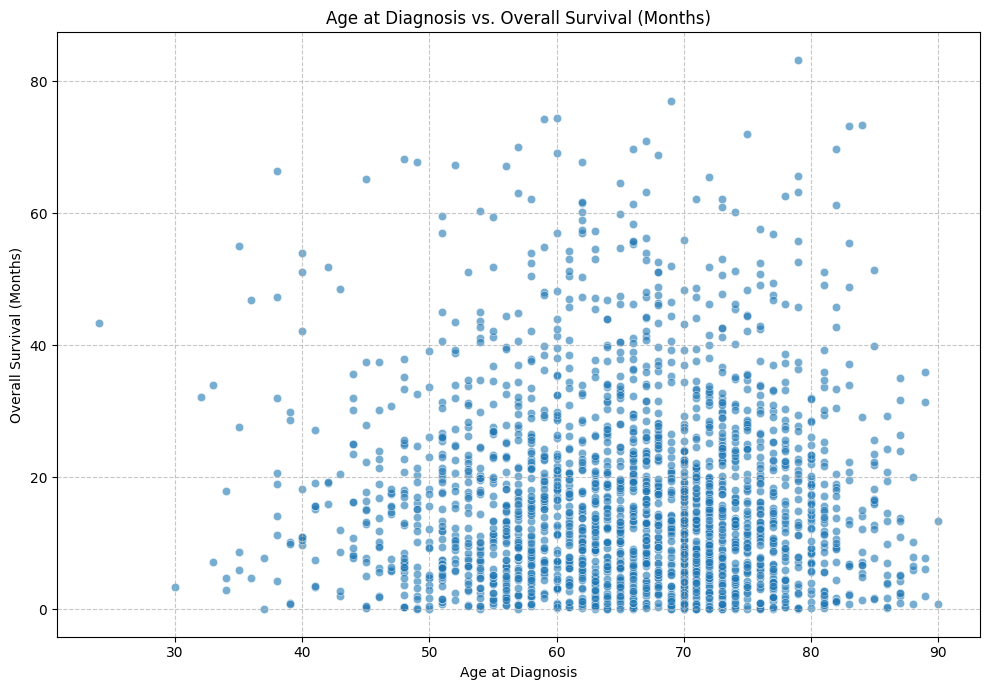

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
        df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# Drop rows with NaN in either column for a clean plot and correlation calculation
df_survival_clean = df.dropna(subset=['Age at Diagnosis', 'Overall Survival (Months)'])

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age at Diagnosis', y='Overall Survival (Months)', data=df_survival_clean, alpha=0.6)
plt.title('Age at Diagnosis vs. Overall Survival (Months)')
plt.xlabel('Age at Diagnosis')
plt.ylabel('Overall Survival (Months)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Ensure 'df' is loaded and columns are numeric for calculation
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
        df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# Calculate Pearson correlation coefficient
correlation = df['Age at Diagnosis'].corr(df['Overall Survival (Months)'])

print(f"Pearson Correlation between Age at Diagnosis and Overall Survival (Months): {correlation:.2f}")

Pearson Correlation between Age at Diagnosis and Overall Survival (Months): -0.02


### Relationship between Age at Diagnosis and Raw Mutational Load (Mutation Count)

This section investigates the continuous relationship between 'Age at Diagnosis' and the 'Mutation Count'. A scatter plot will show the distribution of these two variables against each other, and we will calculate their Pearson correlation coefficient to quantify their linear relationship.

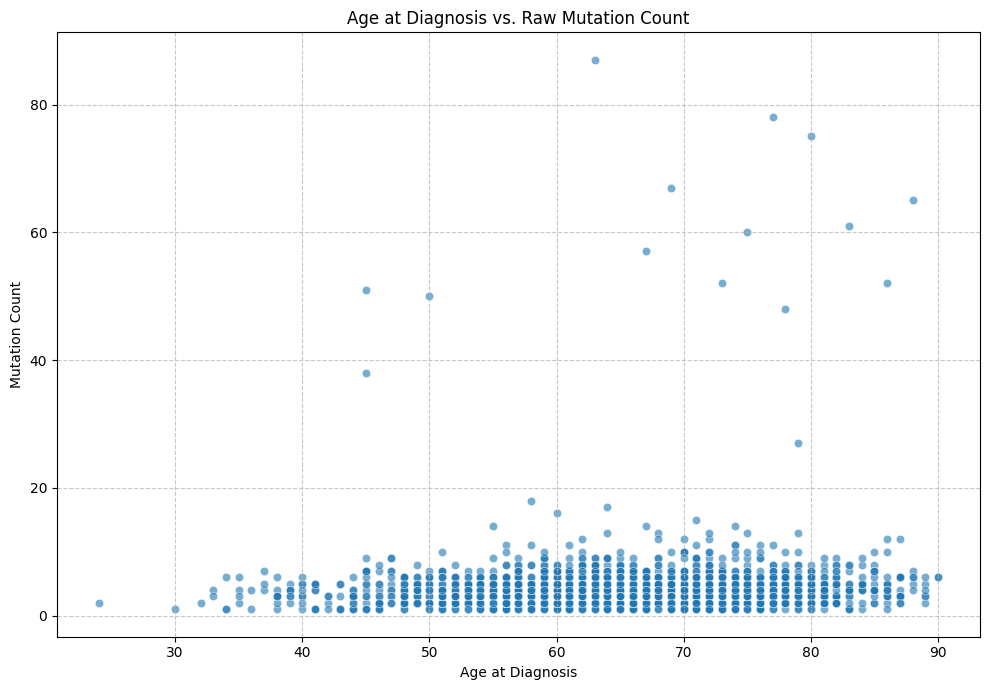

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure 'df' is loaded and columns are numeric
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
        df['Mutation Count'] = pd.to_numeric(df['Mutation Count'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# Drop rows with NaN in either column for a clean plot and correlation calculation
df_mutation_clean = df.dropna(subset=['Age at Diagnosis', 'Mutation Count'])

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age at Diagnosis', y='Mutation Count', data=df_mutation_clean, alpha=0.6)
plt.title('Age at Diagnosis vs. Raw Mutation Count')
plt.xlabel('Age at Diagnosis')
plt.ylabel('Mutation Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Ensure 'df' is loaded and columns are numeric for calculation
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
        df['Mutation Count'] = pd.to_numeric(df['Mutation Count'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# Calculate Pearson correlation coefficient
correlation_age_mutation = df['Age at Diagnosis'].corr(df['Mutation Count'])

print(f"Pearson Correlation between Age at Diagnosis and Mutation Count: {correlation_age_mutation:.2f}")

Pearson Correlation between Age at Diagnosis and Mutation Count: 0.08


### Co-occurrence Analysis and Heatmap of Genomic Alterations

This section generates a co-occurrence matrix heatmap to visualize the relationships between different genomic alterations. We will include categories from 'KRAS Somatic Variant', 'Copy Number State', and 'TMB-H' (Tumor Mutational Burden-High). This helps to identify if certain alterations tend to appear together in the same patients.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Data Preparation for Co-occurrence Matrix ---

# Select relevant columns for co-occurrence analysis
# Note: No direct 'TP53' column was identified in the dataset.
alteration_data = df[['Patient ID', 'KRAS Somatic Variant', 'Copy Number State', 'TMB-H']].copy()

# Handle missing values by treating them as distinct categories or 'Unknown'
alteration_data['KRAS Somatic Variant'] = alteration_data['KRAS Somatic Variant'].fillna('KRAS_Wild-type/Unknown')
alteration_data['Copy Number State'] = alteration_data['Copy Number State'].fillna('CN_Unknown')
alteration_data['TMB-H'] = alteration_data['TMB-H'].fillna('TMB_Unknown')

# One-hot encode the categorical alteration columns
alteration_encoded = pd.get_dummies(alteration_data.set_index('Patient ID'), prefix_sep='_')

# Group by Patient ID and sum to get a binary presence/absence matrix for each alteration per patient
# (in case a patient somehow had multiple entries or we aggregated differently, sum would ensure presence)
patient_alteration_matrix = alteration_encoded.groupby(level=0).max()

print("Patient Alteration Matrix (first 5 rows, first 10 columns):")
display(patient_alteration_matrix.iloc[:5, :10])

Patient Alteration Matrix (first 5 rows, first 10 columns):


,KRAS Somatic Variant_G12C,KRAS Somatic Variant_G12D,KRAS Somatic Variant_G12R,KRAS Somatic Variant_G12V,KRAS Somatic Variant_KRAS_Wild-type/Unknown,KRAS Somatic Variant_Other,KRAS Somatic Variant_Q61H,KRAS Somatic Variant_Q61R,Copy Number State_Amp,Copy Number State_Balanced
Patient ID,,,,,,,,,,
P-0000142,False,True,False,False,False,False,False,False,False,False
P-0000783,False,False,True,False,False,False,False,False,False,False
P-0001304,False,True,False,False,False,False,False,False,False,False
P-0001518,False,True,False,False,False,False,False,False,False,False
P-0001548,False,False,False,True,False,False,False,False,False,False


Co-occurrence Matrix (first 5x5):


,KRAS Somatic Variant_G12C,KRAS Somatic Variant_G12D,KRAS Somatic Variant_G12R,KRAS Somatic Variant_G12V,KRAS Somatic Variant_KRAS_Wild-type/Unknown
KRAS Somatic Variant_G12C,True,False,False,False,False
KRAS Somatic Variant_G12D,False,True,False,False,False
KRAS Somatic Variant_G12R,False,False,True,False,False
KRAS Somatic Variant_G12V,False,False,False,True,False
KRAS Somatic Variant_KRAS_Wild-type/Unknown,False,False,False,False,True


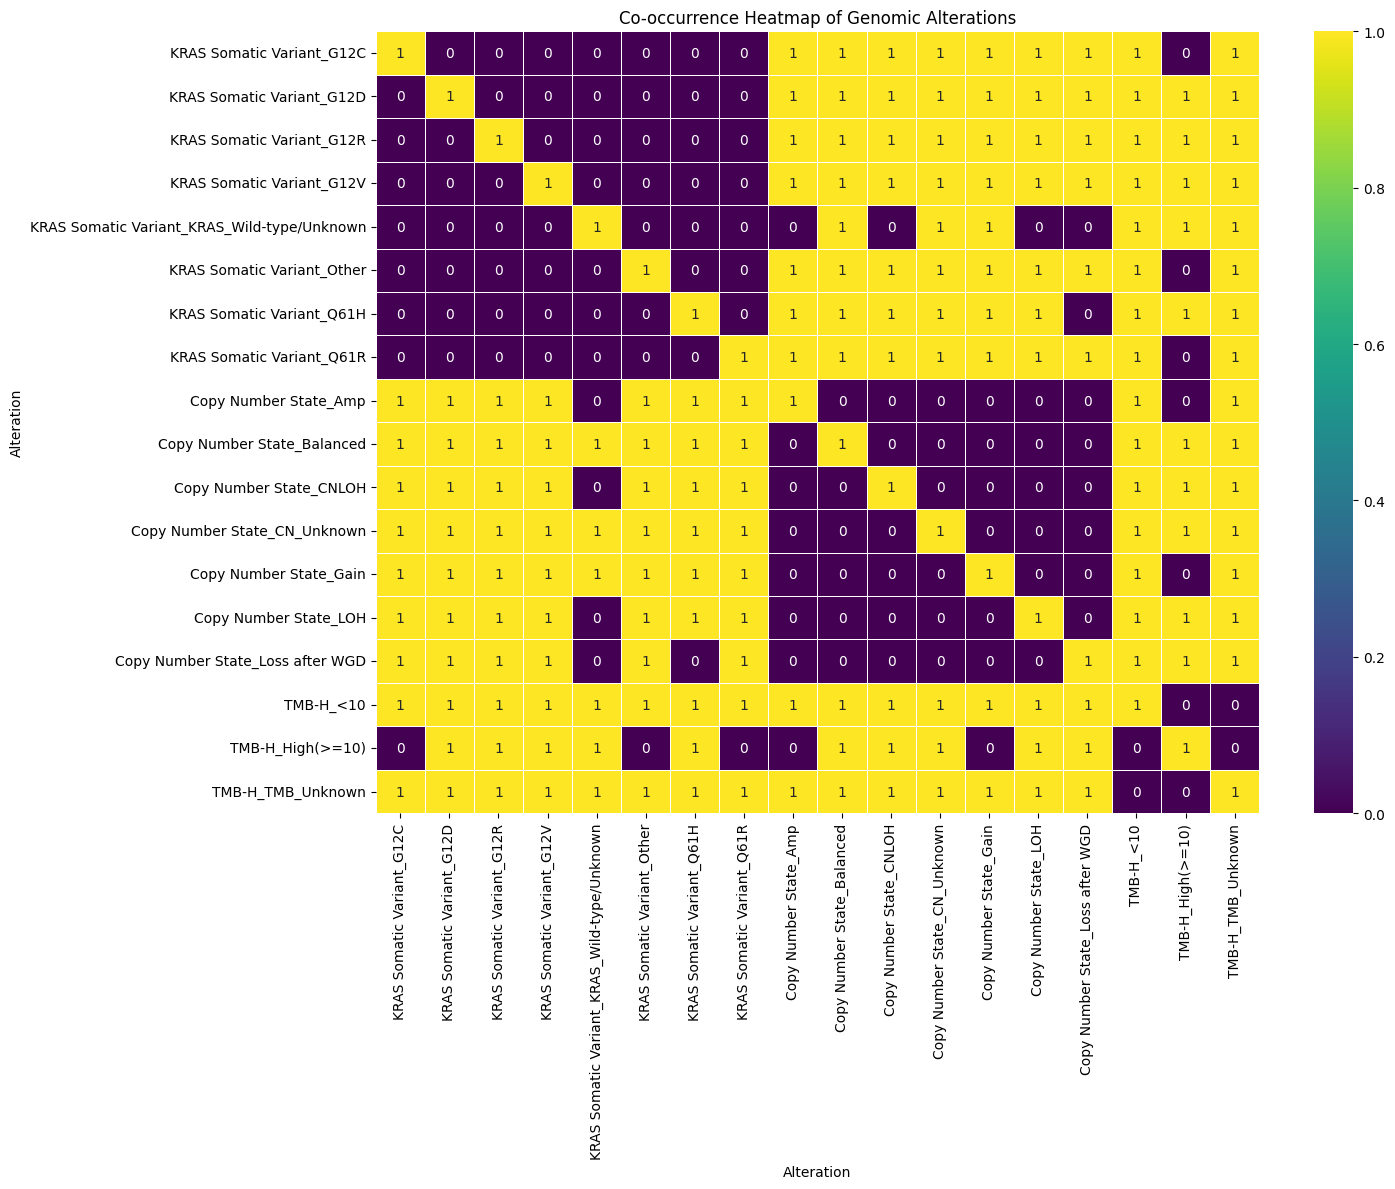

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure patient_alteration_matrix is available (re-run previous cell if needed)
if 'patient_alteration_matrix' not in locals():
    print("Error: 'patient_alteration_matrix' not found. Please run the previous cell first.")
    # Re-creating a dummy for demonstration if running directly, but ideally previous cell runs
    # This block ensures robustness for direct execution after kernel reset, but relies on original df.
    try:
        tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
        df = pd.read_csv(tsv_file_path, sep='\t')
        alteration_data = df[['Patient ID', 'KRAS Somatic Variant', 'Copy Number State', 'TMB-H']].copy()
        alteration_data['KRAS Somatic Variant'] = alteration_data['KRAS Somatic Variant'].fillna('KRAS_Wild-type/Unknown')
        alteration_data['Copy Number State'] = alteration_data['Copy Number State'].fillna('CN_Unknown')
        alteration_data['TMB-H'] = alteration_data['TMB-H'].fillna('TMB_Unknown')
        alteration_encoded = pd.get_dummies(alteration_data.set_index('Patient ID'), prefix_sep='_')
        patient_alteration_matrix = alteration_encoded.groupby(level=0).max()
    except Exception as e:
        print(f"Could not re-create patient_alteration_matrix: {e}")
        raise

# --- Calculate Co-occurrence Matrix ---
# Calculate the co-occurrence matrix: A.T @ A will give counts of pairwise occurrences
co_occurrence_matrix = patient_alteration_matrix.T.dot(patient_alteration_matrix)

# Optionally, normalize by the total number of patients or individual alteration frequency
# For visualization, raw counts or a simple correlation might be more interpretable depending on scale.
# Let's normalize by the frequency of each alteration to get a conditional probability (A and B / A)
# Or, normalize by sqrt(A*B) to get cosine similarity (correlation-like)

# For simplicity and clear visualization of 'co-occurrence' counts, we'll start with raw counts.
# If a correlation-like measure is preferred, we can adjust.

print("Co-occurrence Matrix (first 5x5):")
display(co_occurrence_matrix.iloc[:5, :5])

# --- Generate Heatmap ---
plt.figure(figsize=(15, 12))
sns.heatmap(co_occurrence_matrix, annot=True, cmap='viridis', fmt='g', linewidths=.5)
plt.title('Co-occurrence Heatmap of Genomic Alterations')
plt.xlabel('Alteration')
plt.ylabel('Alteration')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Ensure 'df' is loaded (robustness)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
        df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')
        df['Mutation Count'] = pd.to_numeric(df['Mutation Count'], errors='coerce')
        df['TMB (nonsynonymous)'] = pd.to_numeric(df['TMB (nonsynonymous)'], errors='coerce')
        df['Fraction Genome Altered'] = pd.to_numeric(df['Fraction Genome Altered'], errors='coerce')

    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# Define target and feature columns
target_column = 'Overall Survival (Months)'
numerical_features = ['Age at Diagnosis', 'Mutation Count', 'Fraction Genome Altered', 'TMB (nonsynonymous)']
categorical_features = ['Sex', 'Ancestry ', 'KRAS Somatic Variant', 'Copy Number State', 'MSI Type', 'TMB-H']

# Drop rows where the target variable is NaN
df_model = df.dropna(subset=[target_column]).copy()

# Separate features (X) and target (y)
X = df_model[numerical_features + categorical_features]
y = df_model[target_column]

# Preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline with preprocessor and Linear Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
print("\nTraining the Linear Regression model...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display feature importances (for linear models, these are coefficients after scaling)
# Note: This is an approximation and more complex for pipelines with one-hot encoding

# To get feature names after one-hot encoding
onehot_features = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(onehot_features)

# Get coefficients from the linear regression model
coefficients = model.named_steps['regressor'].coef_

# Create a Series of coefficients for better readability
coeff_df = pd.Series(coefficients, index=feature_names)
print("\nTop 10 Feature Coefficients (after scaling/encoding):")
display(coeff_df.abs().sort_values(ascending=False).head(10))



Training the Linear Regression model...
Model training complete.

Model Evaluation:
Mean Squared Error (MSE): 184.53
R-squared (R2): 0.03

Top 10 Feature Coefficients (after scaling/encoding):


,0
Mutation Count,12.336072
TMB (nonsynonymous),12.148276
MSI Type_Instable,8.664462
Copy Number State_Amp,4.770834
MSI Type_Unknown,4.536417
Ancestry _South Asian (SAS),4.318983
TMB-H_Unknown,3.414169
Copy Number State_LOH,3.334725
Copy Number State_Balanced,3.232580
Copy Number State_CNLOH,3.176791


## Continuous Smoothing Survival Curves

Survival analysis is a branch of statistics for analyzing the expected duration of time until one or more events happen. Here, we'll analyze 'Overall Survival (Months)' and demonstrate how continuous variables can influence survival curves.

In [ ]:
# Install lifelines if not already installed
!pip install lifelines

import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'df' is loaded and columns are numeric (for robustness against kernel resets)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
        df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Prepare data for survival analysis ---
# 'Overall Survival (Months)' is the duration (T)
# 'Overall Survival' (object type) needs to be converted to a binary event indicator (E)

# Map '1:DECEASED' to 1 (event occurred) and '0:LIVING' to 0 (censored)
# Handle potential NaNs in 'Overall Survival' by assuming they are censored (0)
# If other values exist, they would need explicit mapping or dropping.
df['event_observed'] = df['Overall Survival'].map({'1:DECEASED': 1, '0:LIVING': 0}).fillna(0).astype(int)

# Drop rows where duration or event status is missing
survival_df = df.dropna(subset=['Overall Survival (Months)', 'event_observed', 'Age at Diagnosis']).copy()

T = survival_df['Overall Survival (Months)']
E = survival_df['event_observed']

print(f"Prepared {len(survival_df)} entries for survival analysis.")
print(f"Number of events observed (deaths): {E.sum()}")
print(f"Number of censored observations: {len(E) - E.sum()}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=08c268f840ac1ee417ec98907bb33f8a05c363148e131bb23e08d01b98246744
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Prepared 2267 entries for survival analysis.
Number of events observed (deaths): 1518
Number of censored observations: 749


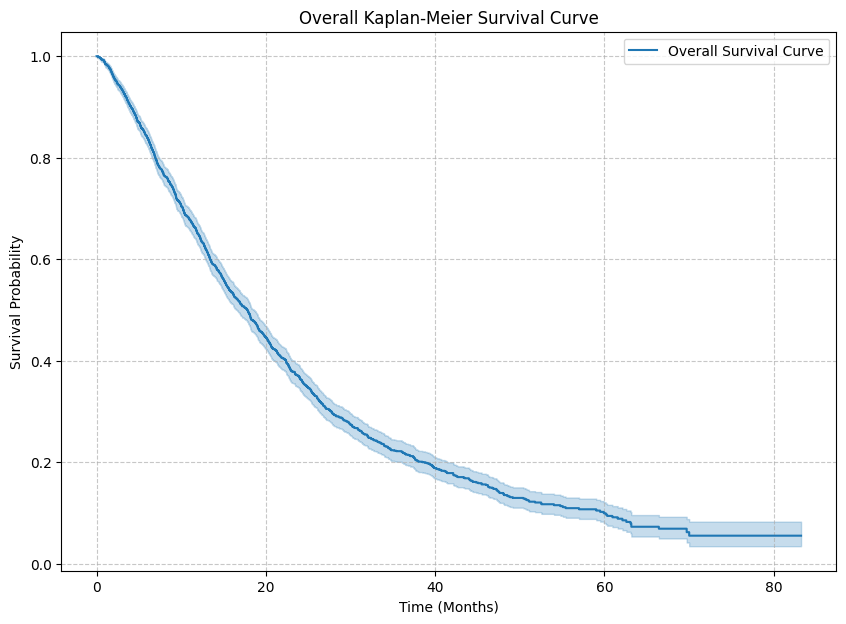

In [ ]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label='Overall Survival Curve')

plt.figure(figsize=(10, 7))
kmf.plot_survival_function()
plt.title('Overall Kaplan-Meier Survival Curve')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1237/3445088273.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in survival_df.groupby('Age_Group'):


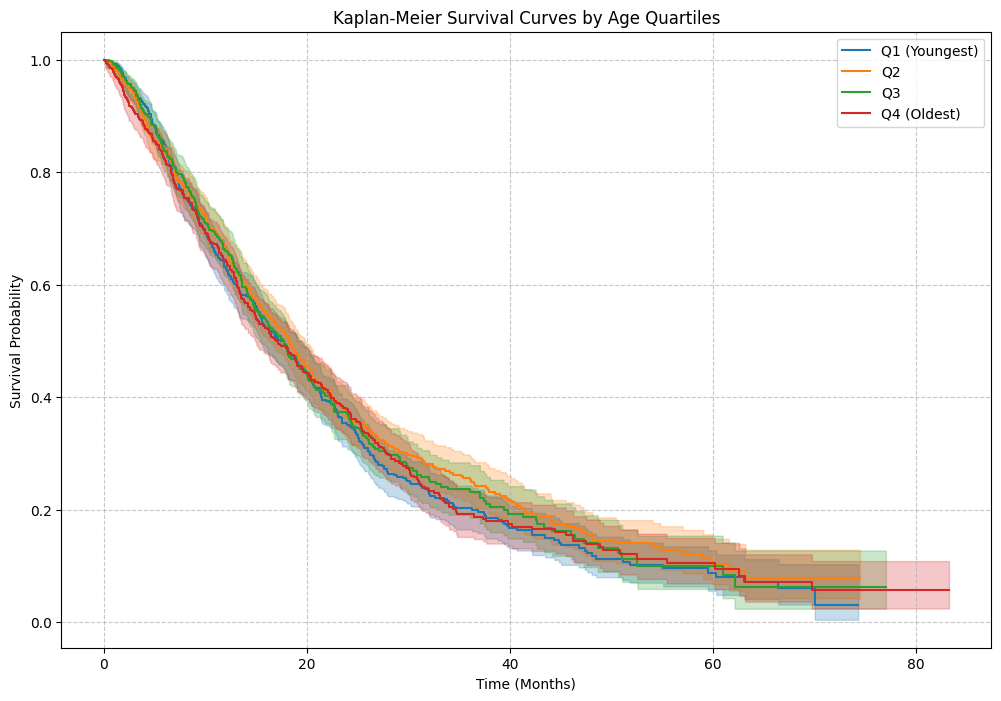

In [ ]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import seaborn as sns

# Create age groups based on quartiles
survival_df['Age_Group'] = pd.qcut(survival_df['Age at Diagnosis'], q=4, labels=['Q1 (Youngest)', 'Q2', 'Q3', 'Q4 (Oldest)'])

plt.figure(figsize=(12, 8))
kmf = KaplanMeierFitter() # Instantiate KMF again for this cell's scope
for name, group in survival_df.groupby('Age_Group'):
    kmf.fit(group['Overall Survival (Months)'], event_observed=group['event_observed'], label=name)
    kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Age Quartiles')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 670 total observations, 156 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 670
number of events observed = 514
   partial log-likelihood = -2862.19
         time fit was run = 2026-08-16 19:53:50 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                         
Age at Diagnosis                  0.01      1.01      0.00           -0.00            0.02                1.00                1.02
Mutation Count                   -0.01      0.99      0.07           -0.15            0.13                0.86                1.14
Fraction Genome Altered           0.89      2.43      0.33            0.23            1.54                1.26                4.66
TMB (nonsynonymous)               0.02      1.02      0.08           -0.14            0.17                0.87                1.19
Sex_Male                          0.18      1.20      0.09            0.00            0.37                1.00                1.44
Ancestry _African (AFR)           0.25      1.28      0.25           -0.25            0.74                0.78                2.10
Ancestry _East Asian (EAS)        0.09      1.10      0.25           -0.39            0.58                0.68                1.78
Ancestry _European (EUR)         -0.10      0.91      0.16           -0.40            0.21                0.67                1.23
Ancestry _South Asian (SAS)       0.20      1.22      0.57           -0.92            1.31                0.40                3.71
KRAS Somatic Variant_G12D         0.18      1.20      0.37           -0.54            0.91                0.58                2.48
KRAS Somatic Variant_G12R        -0.21      0.81      0.38           -0.95            0.54                0.39                1.71
KRAS Somatic Variant_G12V         0.08      1.09      0.37           -0.64            0.81                0.53                2.25
KRAS Somatic Variant_Other       -0.05      0.95      0.43           -0.90            0.79                0.41                2.21
KRAS Somatic Variant_Q61H        -0.19      0.82      0.43           -1.04            0.65                0.35                1.92
KRAS Somatic Variant_Q61R         0.51      1.67      0.48           -0.43            1.46                0.65                4.30
Copy Number State_Balanced       -0.66      0.52      0.21           -1.07           -0.26                0.34                0.77
Copy Number State_CNLOH           0.12      1.13      0.26           -0.40            0.64                0.67                1.90
Copy Number State_Gain           -0.28      0.76      0.22           -0.70            0.15                0.50                1.16
Copy Number State_LOH            -0.81      0.45      0.24           -1.28           -0.33                0.28                0.72
Copy Number State_Loss after WGD -0.49      0.61      0.27           -1.02            0.04                0.36                1.04
MSI Type_Indeterminate           -0.08      0.93      0.47           -1.00            0.85                0.37                2.33
MSI Type_Instable                -1.66      0.19      1.34           -4.29            0.96                0.01                2.61
MSI Type_Stable                  -0.07      0.93      0.16           -0.40            0.25                0.67                1.28
TMB-H_High(>=10)                 -0.33      0.72      0.65           -1.61            0.95                0.20                2.58

                                  cmp to     z      p  -log2(p)
covariate                                                      
Age at Diagnosis                    0.00  1.70   0.09      3.48
Mutation Coun

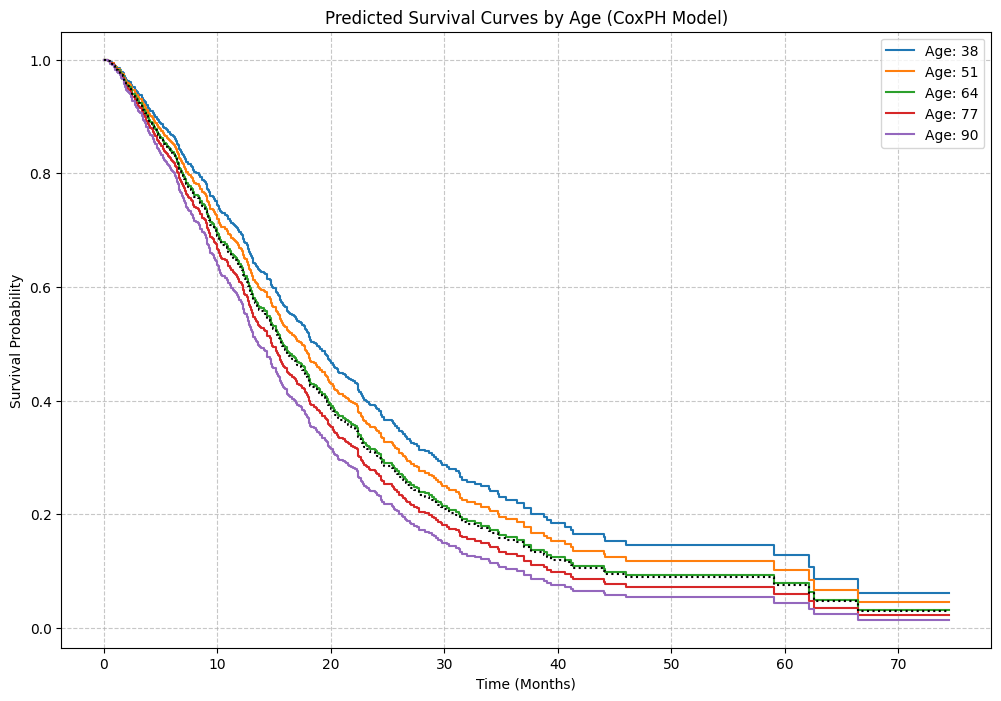

In [ ]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select features for CoxPH model (include numerical and categorical)
cox_features = ['Age at Diagnosis', 'Mutation Count', 'Fraction Genome Altered', 'TMB (nonsynonymous)',
                'Sex', 'Ancestry ', 'KRAS Somatic Variant', 'Copy Number State', 'MSI Type', 'TMB-H']

# Prepare data for CoxPH: drop NaNs for selected features
cph_df = survival_df[cox_features + ['Overall Survival (Months)', 'event_observed']].dropna()

# One-hot encode categorical features for CoxPH model
cph_df_encoded = pd.get_dummies(cph_df, columns=['Sex', 'Ancestry ', 'KRAS Somatic Variant', 'Copy Number State', 'MSI Type', 'TMB-H'], drop_first=True)

# Initialize and fit CoxPH model
cph = CoxPHFitter()
cph.fit(cph_df_encoded, duration_col='Overall Survival (Months)', event_col='event_observed')

print("Cox Proportional Hazards Model Summary:")
cph.print_summary()

# --- Plotting Predicted Survival Curves for different 'Age at Diagnosis' values ---

# Create example subjects for prediction: vary 'Age at Diagnosis' while holding other covariates at their median/mode
median_age = cph_df_encoded['Age at Diagnosis'].median()
min_age = cph_df_encoded['Age at Diagnosis'].min()
max_age = cph_df_encoded['Age at Diagnosis'].max()

# Create a prototype subject by taking the median of numerical features and mode for encoded categoricals
# Need to be careful with encoded columns; a simpler way is to create a base subject and modify age.
base_subject = cph_df_encoded.drop(columns=['Overall Survival (Months)', 'event_observed']).median()
base_subject_df = pd.DataFrame([base_subject])

# Create subjects with different ages
ages_to_predict = np.linspace(min_age, max_age, 5) # 5 different ages across the range

predicted_subjects = pd.DataFrame()
for age in ages_to_predict:
    subject = base_subject_df.copy()
    subject['Age at Diagnosis'] = age
    predicted_subjects = pd.concat([predicted_subjects, subject], ignore_index=True)

# Plot survival functions for these subjects
plt.figure(figsize=(12, 8))
cph.plot_partial_effects_on_outcome(covariates='Age at Diagnosis', values=ages_to_predict, ax=plt.gca())
plt.title('Predicted Survival Curves by Age (CoxPH Model)')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend([f'Age: {int(a)}' for a in ages_to_predict])
plt.show()

### 1. Overall Kaplan-Meier Survival Curve

Let's first visualize the overall survival probability of the cohort using the Kaplan-Meier estimator. This curve shows the probability of a patient surviving beyond a certain time point.

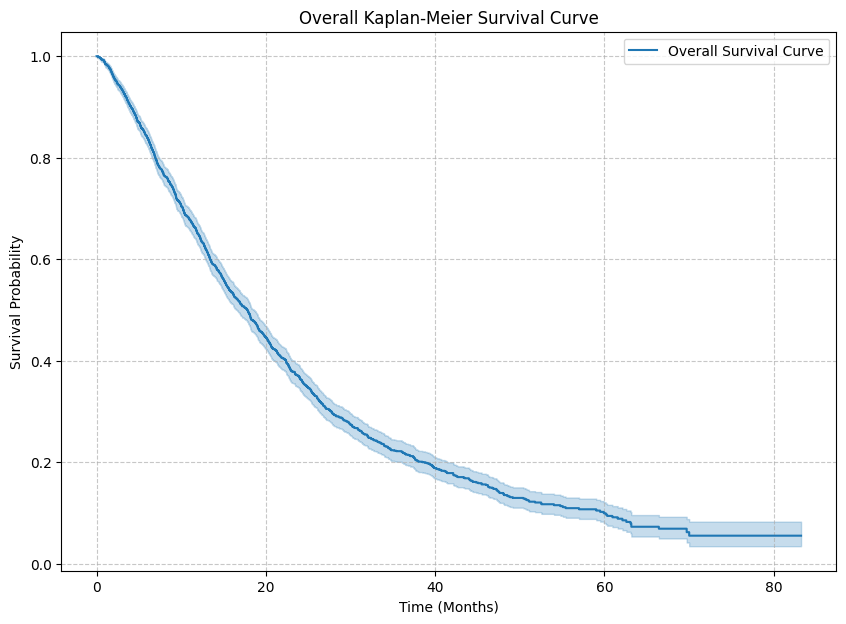

In [ ]:
from lifelines import KaplanMeierFitter # Added for robustness against NameError
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label='Overall Survival Curve')

plt.figure(figsize=(10, 7))
kmf.plot_survival_function()
plt.title('Overall Kaplan-Meier Survival Curve')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 2. Kaplan-Meier Curves Stratified by 'Age at Diagnosis' Quartiles

To see the effect of a continuous variable like 'Age at Diagnosis', we can stratify it into groups (e.g., quartiles) and plot separate Kaplan-Meier curves for each group. This helps visualize how different age ranges impact survival.

/tmp/ipykernel_1237/3548711127.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in survival_df.groupby('Age_Group'):


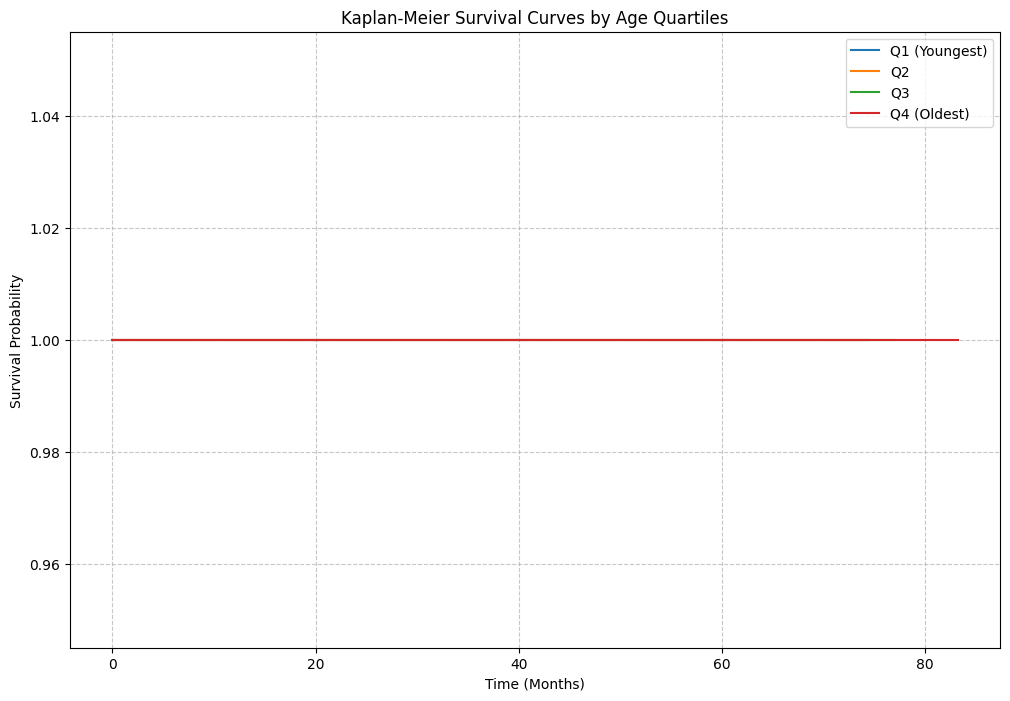

In [ ]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'df' is loaded and columns are numeric (robustness for kernel restarts)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
        df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Re-create data for survival analysis (if not already present) ---
# 'Overall Survival (Months)' is the duration (T)
# 'Overall Survival' (object type) needs to be converted to a binary event indicator (E)
df['event_observed'] = df['Overall Survival'].map({'DECEASED': 1, 'LIVED': 0}).fillna(0).astype(int)

# Drop rows where duration or event status is missing for survival analysis
survival_df = df.dropna(subset=['Overall Survival (Months)', 'event_observed', 'Age at Diagnosis']).copy()

# Create age groups based on quartiles
survival_df['Age_Group'] = pd.qcut(survival_df['Age at Diagnosis'], q=4, labels=['Q1 (Youngest)', 'Q2', 'Q3', 'Q4 (Oldest)'])

plt.figure(figsize=(12, 8))
kmf = KaplanMeierFitter() # Instantiate KMF again for this cell's scope
for name, group in survival_df.groupby('Age_Group'):
    kmf.fit(group['Overall Survival (Months)'], event_observed=group['event_observed'], label=name)
    kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Age Quartiles')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


### 3. Cox Proportional Hazards Model for Continuous Effect

The Cox Proportional Hazards (CoxPH) model directly estimates the effect of covariates (including continuous ones) on the hazard rate. We can then use this model to predict and visualize *smoothed* survival curves for different values of a continuous variable, holding other covariates constant.

Let's fit a CoxPH model including 'Age at Diagnosis' and other features and then visualize predicted survival curves for specific age values.

In [ ]:
# Select features for CoxPH model (include numerical and categorical)
cox_features = ['Age at Diagnosis', 'Mutation Count', 'Fraction Genome Altered', 'TMB (nonsynonymous)',
                'Sex', 'Ancestry ', 'KRAS Somatic Variant', 'Copy Number State', 'MSI Type', 'TMB-H']

# Prepare data for CoxPH: drop NaNs for selected features
cph_df = survival_df[cox_features + ['Overall Survival (Months)', 'event_observed']].dropna()

# One-hot encode categorical features for CoxPH model
cph_df_encoded = pd.get_dummies(cph_df, columns=['Sex', 'Ancestry ', 'KRAS Somatic Variant', 'Copy Number State', 'MSI Type', 'TMB-H'], drop_first=True)

# Initialize and fit CoxPH model
cph = CoxPHFitter()
cph.fit(cph_df_encoded, duration_col='Overall Survival (Months)', event_col='event_observed')

print("Cox Proportional Hazards Model Summary:")
cph.print_summary()

# --- Plotting Predicted Survival Curves for different 'Age at Diagnosis' values ---

# Create example subjects for prediction: vary 'Age at Diagnosis' while holding other covariates at their median/mode
median_age = cph_df_encoded['Age at Diagnosis'].median()
min_age = cph_df_encoded['Age at Diagnosis'].min()
max_age = cph_df_encoded['Age at Diagnosis'].max()

# Create a prototype subject by taking the median of numerical features and mode for encoded categoricals
# Need to be careful with encoded columns; a simpler way is to create a base subject and modify age.
base_subject = cph_df_encoded.drop(columns=['Overall Survival (Months)', 'event_observed']).median()
base_subject_df = pd.DataFrame([base_subject])

# Create subjects with different ages
ages_to_predict = np.linspace(min_age, max_age, 5) # 5 different ages across the range

predicted_subjects = pd.DataFrame()
for age in ages_to_predict:
    subject = base_subject_df.copy()
    subject['Age at Diagnosis'] = age
    predicted_subjects = pd.concat([predicted_subjects, subject], ignore_index=True)

# Plot survival functions for these subjects
plt.figure(figsize=(12, 8))
cph.plot_partial_effects_on_outcome(covariates='Age at Diagnosis', values=ages_to_predict, ax=plt.gca())
plt.title('Predicted Survival Curves by Age (CoxPH Model)')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend([f'Age: {int(a)}' for a in ages_to_predict])
plt.show()


ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

In [ ]:
print("Unique values and their counts in 'Overall Survival' column:")
display(df['Overall Survival'].value_counts(dropna=False))

In [ ]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# Ensure 'df' is loaded and columns are numeric (for robustness against kernel resets)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
        df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# --- Prepare data for survival analysis ---
# 'Overall Survival (Months)' is the duration (T)
# 'Overall Survival' (object type) needs to be converted to a binary event indicator (E)

# Correct mapping for 'event_observed'
df['event_observed'] = df['Overall Survival'].map({'1:DECEASED': 1, '0:LIVING': 0}).fillna(0).astype(int)

# Define all features for CoxPH model, including 'Smoking History'
cox_features = [
    'Age at Diagnosis',
    'Mutation Count',
    'Fraction Genome Altered',
    'TMB (nonsynonymous)',
    'Sex',
    'Ancestry ',
    'KRAS Somatic Variant',
    'Copy Number State',
    'MSI Type',
    'TMB-H',
    'Smoking History' # Added Smoking History
]

# Select only the relevant columns for the CoxPH model (duration, event, and chosen features)
# Then drop NaNs for these selected columns
model_data = df[['Overall Survival (Months)', 'event_observed'] + cox_features].dropna().copy()

# Identify categorical features for one-hot encoding (these must be in cox_features)
categorical_cols = [
    'Sex',
    'Ancestry ',
    'KRAS Somatic Variant',
    'Copy Number State',
    'MSI Type',
    'TMB-H',
    'Smoking History'
]

# One-hot encode categorical features for CoxPH model
cph_df_encoded = pd.get_dummies(model_data, columns=categorical_cols, drop_first=True)

# Initialize and fit CoxPH model
cph = CoxPHFitter()
cph.fit(cph_df_encoded, duration_col='Overall Survival (Months)', event_col='event_observed')

print("Cox Proportional Hazards Model Summary:")
cph.print_summary()

# --- Covariate Risk Comparison ---
print("\n--- Covariate Risk Comparison ---")

# Extract hazard ratios and 95% confidence intervals
summary_df = cph.summary

# Display relevant covariates
comparison_covariates = [
    'Age at Diagnosis',
    'Smoking History_Former/Current',
    'Smoking History_Non-Smoker',
    'Ancestry _African (AFR)',
    'Ancestry _East Asian (EAS)',
    'Ancestry _European (EUR)',
    'Ancestry _South Asian (SAS)'
]

# Filter summary_df for these covariates, handling cases where some might be dropped due to collinearity
filtered_summary = summary_df[summary_df.index.isin(comparison_covariates)].copy()

# Add 'base' categories for interpretation
# The base category for Smoking History is likely 'Never Smoked' or the one that wasn't one-hot encoded.
# For Ancestry, it's the one that wasn't one-hot encoded (e.g., 'Admixed/other' if that was the first alphabetically and drop_first=True). In lifelines, it is the first category in the sorted list of unique values.

print("Hazard Ratios for Key Clinical Risk Factors (relative to baseline categories):")
print("  - A Hazard Ratio (HR) > 1 indicates increased risk.")
print("  - A Hazard Ratio (HR) < 1 indicates decreased risk.")
print("  - HR for continuous variables (like Age) means for each unit increase.")

# Corrected column names for confidence intervals
display(filtered_summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Interpret and compare
print("\n--- Interpretation of Incremental Risk ---")

age_hr = summary_df.loc['Age at Diagnosis', 'exp(coef)']
print(f"*   Age at Diagnosis: For every one-year increase in age, the hazard of an event (death) is multiplied by {age_hr:.3f}. This indicates a slight increase in risk with age.")

# Check if smoking history categories exist before trying to access them
if 'Smoking History_Former/Current' in filtered_summary.index:
    smoking_former_hr = filtered_summary.loc['Smoking History_Former/Current', 'exp(coef)']
    print(f"*   Smoking History (Former/Current vs. Baseline): Individuals who are 'Former/Current' smokers have a hazard ratio of {smoking_former_hr:.3f} compared to the baseline smoking group (likely 'Never Smoked').")

if 'Smoking History_Non-Smoker' in filtered_summary.index:
    smoking_non_hr = filtered_summary.loc['Smoking History_Non-Smoker', 'exp(coef)']
    print(f"*   Smoking History (Non-Smoker vs. Baseline): Individuals who are 'Non-Smoker' have a hazard ratio of {smoking_non_hr:.3f} compared to the baseline smoking group (likely 'Never Smoked').")

print("\nAncestry (relative to the baseline Ancestry group, typically the first alphabetically):")
for idx in filtered_summary.index:
    if idx.startswith('Ancestry '):
        anc_hr = filtered_summary.loc[idx, 'exp(coef)']
        print(f"*   {idx.replace('Ancestry _', '')}: Hazard Ratio = {anc_hr:.3f}")

print("\nComparison Summary:")
print("The hazard ratios allow for a direct comparison of the incremental risk. For instance, you can compare the effect of a specific smoking status or ancestry group to the effect of increasing age by a certain number of years. A larger hazard ratio indicates a stronger association with increased risk.")

### Frequencies of KRAS Somatic Mutations Across Age Decades

This section visualizes how the frequencies (proportions) of different `KRAS Somatic Variant` types change across different age decades. We will approximate "non-linear regression curves" by using `seaborn.regplot` with `lowess=True` for a locally weighted scatterplot smoothing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'df' is loaded and 'Age at Diagnosis' is numeric (robustness against kernel restarts)
tsv_file_path = '/content/pdac_msk_2024_clinical_data.tsv'
if 'df' not in locals() or df.empty:
    try:
        df = pd.read_csv(tsv_file_path, sep='\t')
        df['Age at Diagnosis'] = pd.to_numeric(df['Age at Diagnosis'], errors='coerce')
    except Exception as e:
        print(f"Could not load DataFrame: {e}")
        raise

# Drop rows with NaN in 'Age at Diagnosis' for this analysis
df_kras_age = df.dropna(subset=['Age at Diagnosis', 'KRAS Somatic Variant']).copy()

# Create 'Age Decade' bins (e.g., 20-29, 30-39, etc.)
min_age = int(df_kras_age['Age at Diagnosis'].min())
max_age = int(df_kras_age['Age at Diagnosis'].max())

age_bins = np.arange(min_age // 10 * 10, (max_age // 10 + 1) * 10 + 1, 10)
# Using pd.cut with IntervalIndex output
df_kras_age['Age_Decade_Interval'] = pd.cut(df_kras_age['Age at Diagnosis'], bins=age_bins, right=False)

# To ensure correct string representation for grouping later, convert Interval to string.
# The lambda function then parses this string.
df_kras_age['Age_Decade'] = df_kras_age['Age_Decade_Interval'].astype(str)

# Calculate the total number of patients in each age decade
total_patients_per_decade = df_kras_age.groupby('Age_Decade').size().reset_index(name='Total_Patients')

# Calculate the frequency of each KRAS variant per age decade
kras_frequencies = df_kras_age.groupby(['Age_Decade', 'KRAS Somatic Variant']).size().reset_index(name='Count')

# Merge to get total patients per decade
kras_frequencies = pd.merge(kras_frequencies, total_patients_per_decade, on='Age_Decade')

# Calculate the proportion of each KRAS variant within each age decade
kras_frequencies['Proportion'] = kras_frequencies['Count'] / kras_frequencies['Total_Patients']

print("KRAS Somatic Variant Frequencies per Age Decade (first 10 rows):")
display(kras_frequencies.head(10))

# Convert Age_Decade labels (which are now strings like '[30, 40)') to midpoints
kras_frequencies['Age_Midpoint'] = kras_frequencies['Age_Decade'].apply(lambda x: int(x.split(',')[0].replace('[', '').strip()) + 5)

In [ ]:
plt.figure(figsize=(14, 8))

# Plotting each KRAS variant's proportion across age decades with non-linear regression
for variant in kras_frequencies['KRAS Somatic Variant'].unique():
    variant_data = kras_frequencies[kras_frequencies['KRAS Somatic Variant'] == variant]
    if not variant_data.empty:
        # Using regplot with lowess=True for non-linear regression curves
        sns.regplot(x='Age_Midpoint', y='Proportion', data=variant_data,
                    scatter=False, lowess=True, label=variant, ci=None)
        # Optionally, plot scatter points for actual data points
        # sns.scatterplot(x='Age_Midpoint', y='Proportion', data=variant_data, label=f'{variant} (Points)', alpha=0.6)

plt.title('Proportion of KRAS Somatic Variants Across Age Decades')
plt.xlabel('Age at Diagnosis (Midpoint of Decade)')
plt.ylabel('Proportion of Patients with Variant')
plt.legend(title='KRAS Somatic Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()